EDA

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [15]:
users = pd.read_csv("/Users/palakkakani/Desktop/ML/data/processed/users.csv")
user_activity = pd.read_csv("/Users/palakkakani/Desktop/ML/data/processed/user_activity.csv")
transactions = pd.read_csv("/Users/palakkakani/Desktop/ML/data/processed/transactions.csv")
support_tickets = pd.read_csv("/Users/palakkakani/Desktop/ML/data/processed/support_tickets.csv")
experiment_assignment=pd.read_csv("/Users/palakkakani/Desktop/ML/data/processed/experiment_assignment.csv")

We want all features together in one table to make it easier for exploratory analysis and modeling.

In [16]:
merged_df = pd.merge(users, user_activity, on='user_id', how='left')

In [17]:
merged_df = pd.merge(merged_df, transactions, on='user_id', how='left')

In [18]:
merged_df = pd.merge(merged_df, support_tickets, on='user_id', how='left')

In [19]:
merged_df = pd.merge(merged_df, experiment_assignment, on='user_id', how='left')

In [20]:
merged_df.head()

,user_id,gender,SeniorCitizen,Partner,Dependents,months_active,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,billing_cycle,payment_success,failed_payment_count,chargeback_flag,monthly_revenue,ticket_count,avg_response_time,resolved_flag,experiment_group,experiment_start_month
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,8,1,0,0,29.85,0,36.547521,1,control,1900-02-01
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,9,1,0,0,56.95,0,18.625697,1,control,1900-04-01
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,11,0,0,0,0.00,0,22.353249,1,discount,1900-02-01
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,22,1,0,0,42.30,0,33.769264,1,control,1900-05-01
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,8,1,0,0,70.70,0,44.230280,1,control,1900-05-01


In [21]:
merged_df.shape

(7043, 37)

In [ ]:
# I first merged all the tables to create a single dataset for analysis. 
# Then I checked the shape and missing values to understand data completeness.
print("\nMissing values per column:")
print(merged_df.isnull().sum())


Missing values per column:
user_id                   0
gender                    0
SeniorCitizen             0
Partner                   0
Dependents                0
months_active             0
PhoneService              0
MultipleLines             0
InternetService           0
OnlineSecurity            0
OnlineBackup              0
DeviceProtection          0
TechSupport               0
StreamingTV               0
StreamingMovies           0
subscription_type         0
PaperlessBilling          0
PaymentMethod             0
monthly_price             0
total_revenue             0
churn_label               0
sessions_per_week         0
avg_watch_minutes         0
days_since_last_login     0
preferred_genre           0
device_type               0
number_of_profiles        0
billing_cycle             0
payment_success           0
failed_payment_count      0
chargeback_flag           0
monthly_revenue           0
ticket_count              0
avg_response_time         0
resolved_flag       

In [23]:
churn_by_sub = merged_df.groupby('subscription_type')['churn_label'].mean().reset_index()
print(churn_by_sub)

  subscription_type  churn_label
0    Month-to-month     0.427097
1          One year     0.112695
2          Two year     0.028319


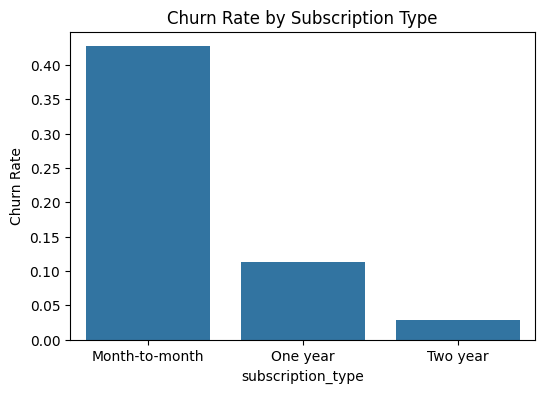

In [24]:
plt.figure(figsize=(6,4))
sns.barplot(x='subscription_type', y='churn_label', data=churn_by_sub)
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Subscription Type')
plt.show()

In [ ]:
# Which subscription type loses more users?
# Month to Month subscription type tends to churn more then one year and two year subscription plans 

Funnel Analysis

In [ ]:
# Define funnel stages
#Convert raw activity into funnel stages: signup → active → engaged → retained.
merged_df['stage_signup'] = 1  # everyone signed up
merged_df['stage_active'] = (merged_df['sessions_per_week'] > 0).astype(int)
merged_df['stage_engaged'] = (merged_df['avg_watch_minutes'] >= 30).astype(int)
merged_df['stage_retained'] = (merged_df['churn_label'] == 0).astype(int)

In [29]:
# Compute funnel percentages
funnel = pd.DataFrame({
    'Stage': ['Signup','Active','Engaged','Retained'],
    'Users': [
        merged_df['stage_signup'].sum(),
        merged_df['stage_active'].sum(),
        merged_df['stage_engaged'].sum(),
        merged_df['stage_retained'].sum()
    ]
})

In [30]:
funnel['Percentage'] = (funnel['Users'] / funnel['Users'].iloc[0] * 100).round(2)
print(funnel)

      Stage  Users  Percentage
0    Signup   7043      100.00
1    Active   7002       99.42
2   Engaged   5300       75.25
3  Retained   5174       73.46


Here we see the funnel from signup to retained users. The width of each stage represents how many users make it. This visualization helps us quickly identify at which stage users drop off and where we should focus retention strategies.

/var/folders/5f/yfl9x7p9311gz93ctr_bp39m0000gn/T/ipykernel_42242/1026806724.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stage', y='Percentage', data=funnel, palette='Blues_d')


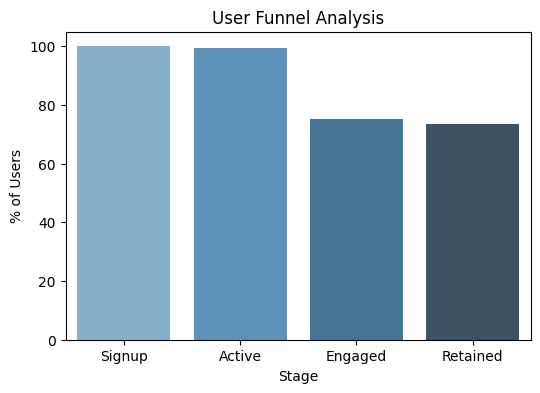

In [31]:
# Plot funnel
plt.figure(figsize=(6,4))
sns.barplot(x='Stage', y='Percentage', data=funnel, palette='Blues_d')
plt.title('User Funnel Analysis')
plt.ylabel('% of Users')
plt.show()

In [ ]:
churn_counts = merged_df['churn_label'].value_counts()
print(churn_counts)
#This shows the proportion of users who churn versus those who stay.

churn_label
0    5174
1    1869
Name: count, dtype: int64


/var/folders/5f/yfl9x7p9311gz93ctr_bp39m0000gn/T/ipykernel_42242/4095439031.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn_label', data=merged_df, palette='Set2')


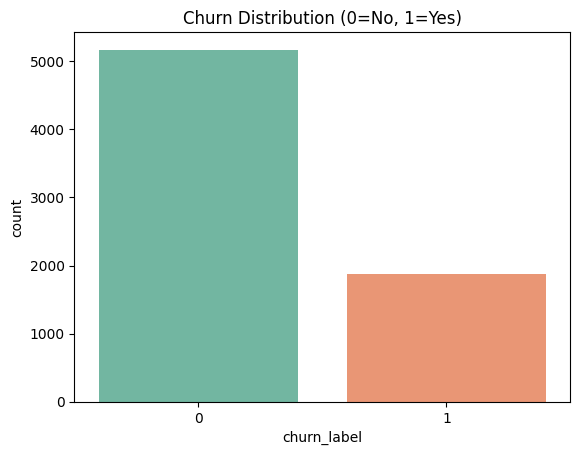

In [41]:

sns.countplot(x='churn_label', data=merged_df, palette='Set2')
plt.title("Churn Distribution (0=No, 1=Yes)")
plt.show()

In [38]:
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 7043 non-null   object 
 1   gender                  7043 non-null   object 
 2   SeniorCitizen           7043 non-null   int64  
 3   Partner                 7043 non-null   object 
 4   Dependents              7043 non-null   object 
 5   months_active           7043 non-null   int64  
 6   PhoneService            7043 non-null   object 
 7   MultipleLines           7043 non-null   object 
 8   InternetService         7043 non-null   object 
 9   OnlineSecurity          7043 non-null   object 
 10  OnlineBackup            7043 non-null   object 
 11  DeviceProtection        7043 non-null   object 
 12  TechSupport             7043 non-null   object 
 13  StreamingTV             7043 non-null   object 
 14  StreamingMovies         7043 non-null   

In [42]:
merged_df['tenure_bucket'] = pd.cut(merged_df['months_active'], bins=[0,6,12,24,36,100], labels=['0-6','6-12','12-24','24-36','36+'])
tenure_churn = merged_df.groupby('tenure_bucket')['churn_label'].mean().reset_index()

/var/folders/5f/yfl9x7p9311gz93ctr_bp39m0000gn/T/ipykernel_42242/897925699.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = merged_df.groupby('tenure_bucket')['churn_label'].mean().reset_index()


/var/folders/5f/yfl9x7p9311gz93ctr_bp39m0000gn/T/ipykernel_42242/865832715.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tenure_bucket', y='churn_label', data=tenure_churn, palette='magma')


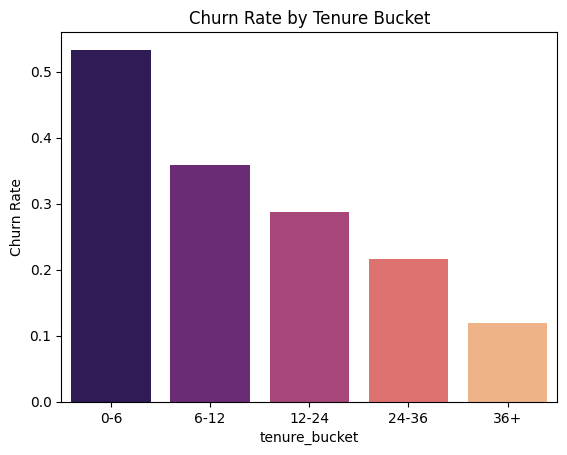

In [43]:
sns.barplot(x='tenure_bucket', y='churn_label', data=tenure_churn, palette='magma')
plt.title("Churn Rate by Tenure Bucket")
plt.ylabel("Churn Rate")
plt.show()

Early churn vs long-term churn. Helps design retention strategies for new vs old users.

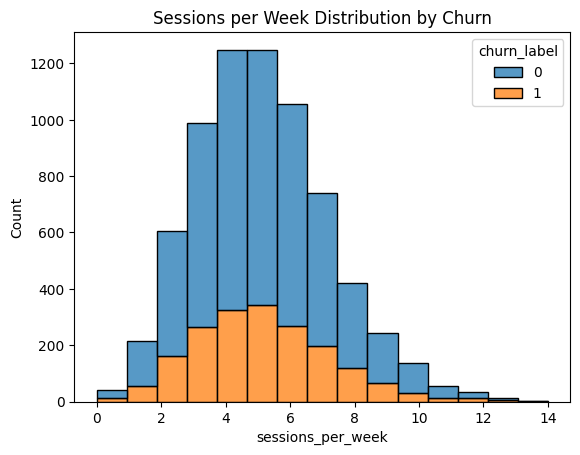

In [45]:
# Sessions per week histogram
sns.histplot(data=merged_df, x='sessions_per_week', hue='churn_label', multiple='stack', bins=15)
plt.title("Sessions per Week Distribution by Churn")
plt.show()

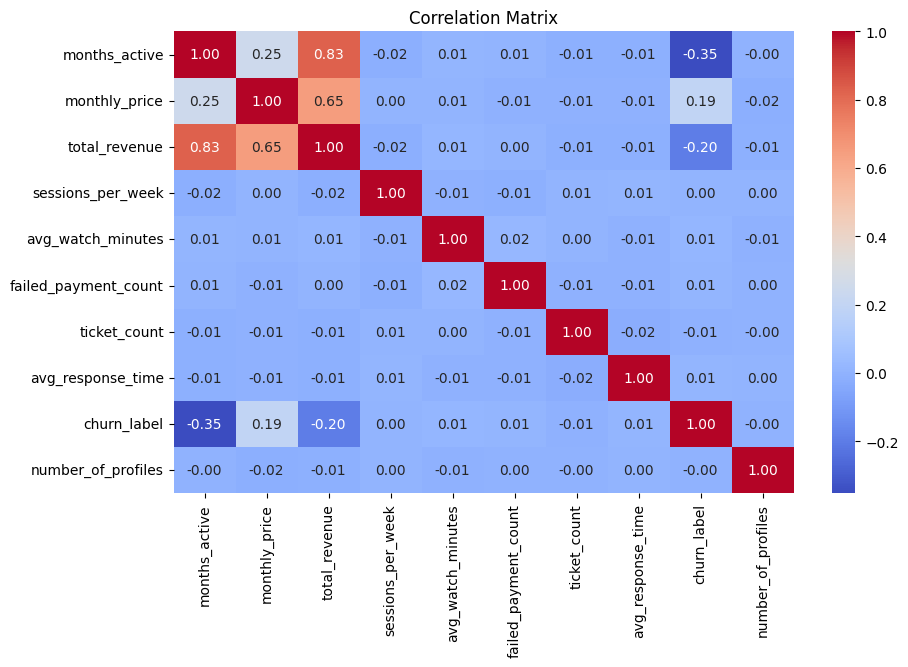

In [48]:
numeric_cols = ['months_active','monthly_price','total_revenue','sessions_per_week','avg_watch_minutes',
                'failed_payment_count','ticket_count','avg_response_time','churn_label','number_of_profiles']

plt.figure(figsize=(10,6))
sns.heatmap(merged_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The heatmap shows correlations between numeric features. Strongly correlated features with churn can be important predictors in our model.

In [50]:
# Save cleaned/merged data for next steps
merged_df.to_csv("/Users/palakkakani/Desktop/ML/data/processed/merged_cleaned.csv", index=False)